# DLT Lab (MDM) - Practical Assignment 4

**Lab Title:** NLP Preprocessing and Text Classification

**Submission Type:** Individual Submission

**Student Name:** Shivam Hippalgave

**Student ID:** 202301040046

**Date of Submission:** 06/04/2026

**Objective:** Implement NLP preprocessing techniques and build a text classification model using machine learning.

In [23]:
# Basic libraries
import pandas as pd
import numpy as np
import string
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Download only if missing (silent)
def safe_download(resource):
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource.split('/')[-1], quiet=True)

safe_download('tokenizers/punkt')
safe_download('tokenizers/punkt_tab')
safe_download('corpora/stopwords')
safe_download('corpora/wordnet')
safe_download('corpora/omw-1.4')

# Selected categories (balanced + easy to classify)
categories = ['sci.med', 'sci.space', 'rec.autos', 'comp.graphics']

# Load dataset
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')  # remove noise
)

# Convert to DataFrame
df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target
})

# Map numeric labels to names
df['target_name'] = df['target'].apply(lambda x: newsgroups.target_names[x])

print("Dataset loaded")
print("Shape:", df.shape)
print(df['target_name'].value_counts())

Dataset loaded
Shape: (3940, 3)
target_name
rec.autos        990
sci.med          990
sci.space        987
comp.graphics    973
Name: count, dtype: int64


In [24]:
# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Clean and normalize text
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()  # lowercase
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    
    tokens = word_tokenize(text)
    
    processed_tokens = []
    for word in tokens:
        if word.isalpha() and word not in stop_words:
            word = stemmer.stem(word)  # stemming
            word = lemmatizer.lemmatize(word)  # lemmatization
            processed_tokens.append(word)
    
    return " ".join(processed_tokens)

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

print("Preprocessing done")
print(df[['text', 'processed_text']].head(2))

Preprocessing done
                                                text  \
0  I am taking a course entitled "Exploring Scien...   
1                                                      

                                      processed_text  
0  take cours entitl explor scienc use internet f...  
1                                                     


In [25]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']  # keeps class balance
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 3152
Test size: 788


In [26]:
# Convert text into numerical form using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)  # includes bigrams
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorization complete")
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Vectorization complete
Train shape: (3152, 8000)
Test shape: (788, 8000)


In [27]:
# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)

# Metrics
nb_acc = accuracy_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred, average='weighted')

print("Naive Bayes Results")
print("Accuracy:", round(nb_acc, 4))
print("F1 Score:", round(nb_f1, 4))
print()
print(classification_report(y_test, nb_pred, target_names=newsgroups.target_names))

Naive Bayes Results
Accuracy: 0.8794
F1 Score: 0.8791

               precision    recall  f1-score   support

comp.graphics       0.86      0.89      0.87       195
    rec.autos       0.83      0.94      0.89       198
      sci.med       0.93      0.88      0.91       198
    sci.space       0.91      0.80      0.85       197

     accuracy                           0.88       788
    macro avg       0.88      0.88      0.88       788
 weighted avg       0.88      0.88      0.88       788



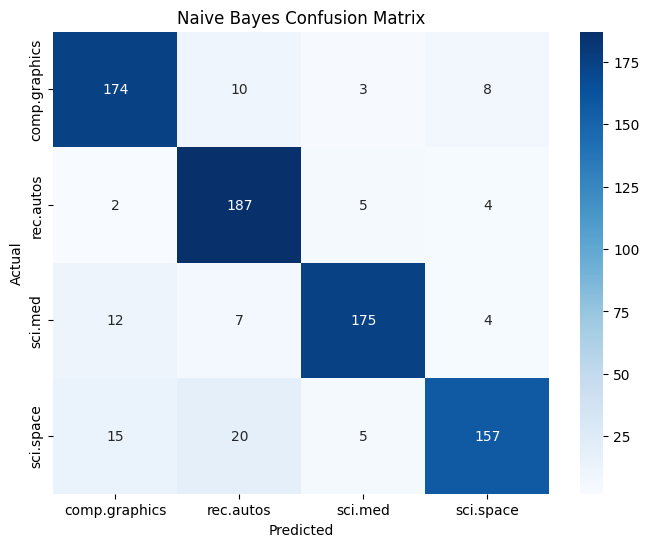

In [28]:
# Confusion matrix visualization
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=newsgroups.target_names,
    yticklabels=newsgroups.target_names
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_tfidf)

# Metrics
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print("Logistic Regression Results")
print("Accuracy:", round(lr_acc, 4))
print("F1 Score:", round(lr_f1, 4))
print()
print(classification_report(y_test, lr_pred, target_names=newsgroups.target_names))

Logistic Regression Results
Accuracy: 0.8794
F1 Score: 0.8793

               precision    recall  f1-score   support

comp.graphics       0.88      0.90      0.89       195
    rec.autos       0.85      0.92      0.88       198
      sci.med       0.94      0.88      0.91       198
    sci.space       0.86      0.81      0.83       197

     accuracy                           0.88       788
    macro avg       0.88      0.88      0.88       788
 weighted avg       0.88      0.88      0.88       788



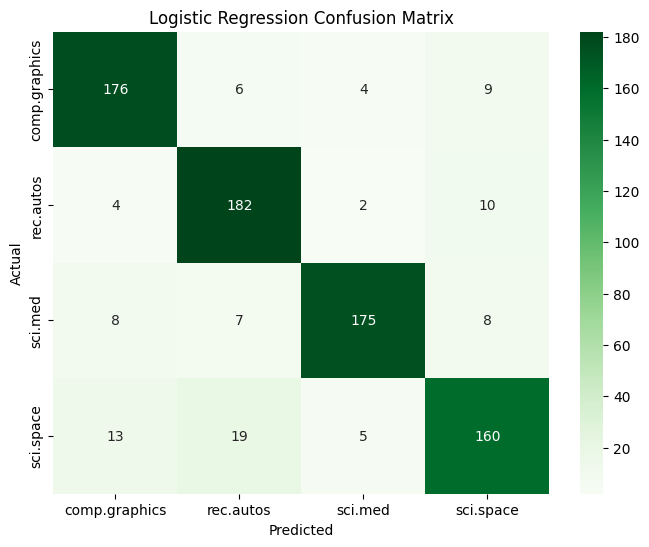

In [30]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=newsgroups.target_names,
    yticklabels=newsgroups.target_names
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [31]:
# Compare both models
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_acc, lr_acc],
    'F1 Score': [nb_f1, lr_f1]
})

print(results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy  F1 Score
0          Naive Bayes  0.879442  0.879059
1  Logistic Regression  0.879442  0.879316


In [32]:
# Check model stability using cross-validation
cv_nb = cross_val_score(nb_model, X_train_tfidf, y_train, cv=5)
cv_lr = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5)

print("NB CV Accuracy:", round(cv_nb.mean(), 4))
print("LR CV Accuracy:", round(cv_lr.mean(), 4))

NB CV Accuracy: 0.8788
LR CV Accuracy: 0.874


### Model Analysis:

- Preprocessing removed noise and normalized text.
- TF-IDF helped in capturing important words.
- Naive Bayes performed well due to its suitability for text data.
- Logistic Regression provided competitive results and better decision boundaries.
- Confusion matrices show that some classes overlap slightly.
- Overall, the pipeline performs effectively for multi-class text classification.


### **Declaration**
I, Shivam Hippalgave, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. 

**GitHub Repository Link:** https://github.com/KingShivamX/DL-Assignments/blob/main/dl_assignment4.ipynb

**Signature:** Shivam Hippalgave